# Kinsun Speech Evaluation

本 Notebook 僅使用 Synthetic／已去識別資料，比較逐字 CER、正規化 CER、關鍵詞、否定詞、人工語意判定與延遲。CER 高不一定代表語意完全錯誤，因此不可只用單一分數決定是否訓練 LoRA。

In [1]:
from pathlib import Path
import difflib
import importlib.util
import json

import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Audio, HTML, display

# 從目前工作目錄往上尋找 repository 根目錄，避免使用者從不同目錄啟動 Jupyter 時找不到評測程式。
repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'evals/speech/evaluate_transcript.py').exists())
module_path = repo_root / 'evals/speech/evaluate_transcript.py'
spec = importlib.util.spec_from_file_location('speech_eval', module_path)
speech_eval = importlib.util.module_from_spec(spec)
spec.loader.exec_module(speech_eval)
case_path = repo_root / 'evals/speech/synthetic_cases.jsonl'
report_root = repo_root / 'evals/reports'
report_root.mkdir(parents=True, exist_ok=True)

In [2]:
# 這條線只協助閱讀圖表，不是產品驗收門檻；正式門檻必須經 Owner 核准並記錄在 Speech performance ADR。
DISPLAY_CER_GUIDE = 0.30
# 圖表尺寸只影響顯示，不會改變任何評測計算。
FIGURE_SIZE = (10, 5)

In [3]:
cases = [json.loads(line) for line in case_path.read_text(encoding='utf-8').splitlines() if line.strip()]
results = [speech_eval.evaluate_case(case) for case in cases]
results_df = pd.DataFrame(results)
display(results_df[['case_id', 'language', 'model_id', 'raw_hanji_cer', 'normalized_hanji_cer', 'keyword_recall', 'negation_recall', 'semantic_intent_correct', 'latency_ms']])

,case_id,language,model_id,raw_hanji_cer,normalized_hanji_cer,keyword_recall,negation_recall,semantic_intent_correct,latency_ms
0,nan-interruption-001,nan-TW,adi-gov-tw/Taiwan-Tongues-ASR-CE-pretrained-v2.0,0.857143,0.833333,0.0,0.0,True,550


C:\Users\clyan\AppData\Local\Temp\ipykernel_50976\271508725.py:8: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\clyan\AppData\Local\Temp\ipykernel_50976\271508725.py:8: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\clyan\AppData\Local\Temp\ipykernel_50976\271508725.py:8: UserWarning: Glyph 37679 (\N{CJK UNIFIED IDEOGRAPH-932F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\clyan\AppData\Local\Temp\ipykernel_50976\271508725.py:8: UserWarning: Glyph 35492 (\N{CJK UNIFIED IDEOGRAPH-8AA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\clyan\AppData\Local\Temp\ipykernel_50976\271508725.py:8: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\clyan\AppData\Local\Temp\ipykernel_50976\271508725.py:8: UserWarning: Glyph 27604 (\N{CJK UNIFIE

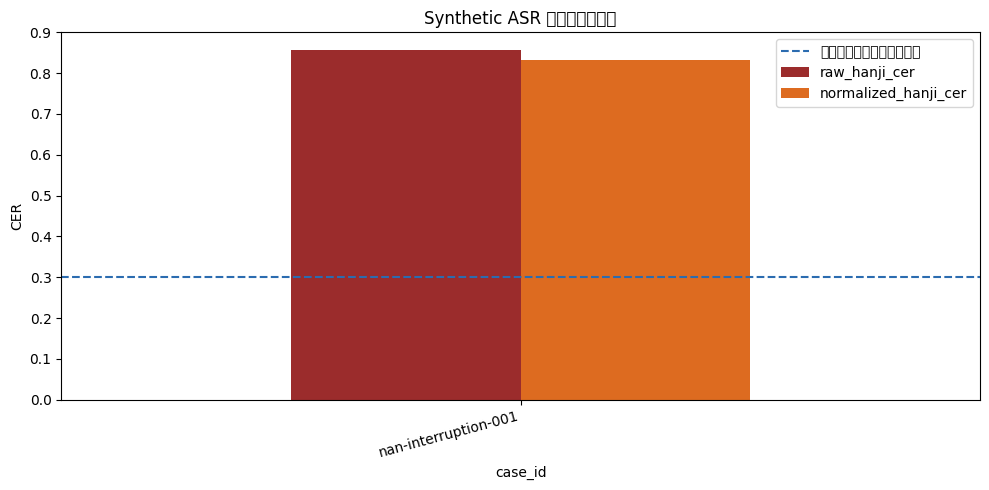

In [4]:
chart = results_df.set_index('case_id')[['raw_hanji_cer', 'normalized_hanji_cer']]
axis = chart.plot(kind='bar', figsize=FIGURE_SIZE, color=['#9B2C2C', '#DD6B20'])
axis.axhline(DISPLAY_CER_GUIDE, color='#2B6CB0', linestyle='--', label='顯示參考線（非驗收門檻）')
axis.set_ylabel('CER')
axis.set_title('Synthetic ASR 字元錯誤率比較')
axis.legend()
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

In [5]:
def colored_diff(reference: str, hypothesis: str) -> HTML:
    # 使用 HTML 顏色區分刪除、插入及替換，讓評測者能快速定位 CER 的來源；內容先跳脫，避免文字被當成 HTML 執行。
    import html
    parts = []
    for opcode, i1, i2, j1, j2 in difflib.SequenceMatcher(None, reference, hypothesis).get_opcodes():
        ref_text = html.escape(reference[i1:i2])
        hyp_text = html.escape(hypothesis[j1:j2])
        if opcode == 'equal':
            parts.append(ref_text)
        elif opcode == 'delete':
            parts.append(f"<del style='background:#FED7D7'>{ref_text}</del>")
        elif opcode == 'insert':
            parts.append(f"<ins style='background:#C6F6D5'>{hyp_text}</ins>")
        else:
            parts.append(f"<del style='background:#FED7D7'>{ref_text}</del><ins style='background:#C6F6D5'>{hyp_text}</ins>")
    return HTML("<div style='font-size:20px;line-height:1.8'>" + ''.join(parts) + '</div>')

## 互動式單筆評測 GUI

輸入參考逐字稿與模型輸出後，即時查看指標、文字差異與圖表。可附加 Synthetic／已去識別 WAV 供人工聆聽，但不會上傳 AWS 或自動寫入正式報告。

In [6]:
# 預先帶入第一筆 Synthetic 案例，讓使用者開啟 Notebook 後不必先準備資料即可操作。
example = cases[0]
language_input = widgets.Dropdown(options=['zh-TW', 'nan-TW', 'hak-TW', 'en-US'], value=example['language'], description='語言')
reference_input = widgets.Textarea(value=example['reference_hanji'], description='正確逐字稿', layout=widgets.Layout(width='95%', height='90px'))
hypothesis_input = widgets.Textarea(value=example['asr_raw_output'], description='ASR 輸出', layout=widgets.Layout(width='95%', height='90px'))
keywords_input = widgets.Text(value=', '.join(example['required_keywords']), description='關鍵詞', layout=widgets.Layout(width='95%'))
negations_input = widgets.Text(value=', '.join(example['required_negations']), description='否定詞', layout=widgets.Layout(width='95%'))
model_input = widgets.Text(value=example['model']['model_id'], description='模型 ID', layout=widgets.Layout(width='95%'))
revision_input = widgets.Text(value=example['model']['revision'], description='模型版本', layout=widgets.Layout(width='95%'))
latency_input = widgets.BoundedFloatText(value=example['latency_ms'], min=0, max=600000, step=10, description='延遲 ms')
semantic_input = widgets.Dropdown(options=[('尚未人工判定', None), ('語意正確', True), ('語意錯誤', False)], value=example['semantic_intent_correct'], description='語意判定')
audio_input = widgets.FileUpload(accept='.wav,audio/wav', multiple=False, description='Synthetic WAV')
run_button = widgets.Button(description='執行單筆評測', button_style='primary', icon='check')
gui_output = widgets.Output()

def split_terms(value: str) -> list[str]:
    # 同時接受半形及全形逗號，並移除空白項目，避免使用者輸入格式差異造成假的漏詞結果。
    return [term.strip() for term in value.replace('，', ',').split(',') if term.strip()]

def run_evaluation(_button) -> None:
    # interactive-not-saved 明確表示這筆資料只存在記憶體；需要正式比較時，應新增有來源聲明及穩定 case_id 的 JSONL 案例。
    case = {
        'case_id': 'interactive-not-saved', 'language': language_input.value,
        'reference_hanji': reference_input.value, 'reference_tailo': None,
        'asr_raw_output': hypothesis_input.value, 'asr_tailo_output': None,
        'required_keywords': split_terms(keywords_input.value),
        'required_negations': split_terms(negations_input.value),
        'semantic_intent_correct': semantic_input.value,
        'model': {'model_id': model_input.value, 'revision': revision_input.value},
        'latency_ms': latency_input.value,
    }
    with gui_output:
        gui_output.clear_output(wait=True)
        if not reference_input.value.strip():
            print('正確逐字稿不可為空，請輸入 Synthetic／已去識別內容。')
            return
        result = speech_eval.evaluate_case(case)
        table = pd.DataFrame([{
            'Raw CER': result['raw_hanji_cer'], 'Normalized CER': result['normalized_hanji_cer'],
            '關鍵詞召回率': result['keyword_recall'], '否定詞召回率': result['negation_recall'],
            '人工語意判定': result['semantic_intent_correct'], '延遲 ms': result['latency_ms'],
        }])
        display(table.style.format({'Raw CER': '{:.1%}', 'Normalized CER': '{:.1%}', '關鍵詞召回率': '{:.1%}', '否定詞召回率': '{:.1%}'}, na_rep='N/A'))
        display(colored_diff(result['reference_hanji'], result['asr_raw_output']))
        values = pd.Series({'Raw CER': result['raw_hanji_cer'], 'Normalized CER': result['normalized_hanji_cer'], '關鍵詞召回率': result['keyword_recall'] or 0, '否定詞召回率': result['negation_recall'] or 0})
        axis = values.plot(kind='bar', figsize=(9, 4), color=['#9B2C2C', '#DD6B20', '#2B6CB0', '#2F855A'])
        axis.set_ylim(0, max(1, float(values.max()) * 1.1)); axis.set_ylabel('比率'); axis.set_title('單筆 Speech Eval 結果')
        plt.xticks(rotation=15, ha='right'); plt.tight_layout(); plt.show()
        if audio_input.value:
            # 音訊只從瀏覽器記憶體傳給目前 Kernel 播放，不由本儲存格寫入 repository 或一般 Log。
            display(Audio(data=bytes(audio_input.value[0]['content']), autoplay=False))

run_button.on_click(run_evaluation)
display(widgets.VBox([language_input, reference_input, hypothesis_input, keywords_input, negations_input, model_input, revision_input, widgets.HBox([latency_input, semantic_input]), audio_input, run_button, gui_output]))

In [7]:
# 批次結果才會寫入可稽核報告；GUI 中未保存的臨時輸入不會混入正式證據。
csv_path = report_root / 'speech-evaluation-summary.csv'
html_path = report_root / 'speech-evaluation-summary.html'
json_path = report_root / 'speech-evaluation-summary.json'
results_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
results_df.to_html(html_path, index=False, escape=True)
json_path.write_text(json.dumps({'schema_version': '1.0', 'results': results}, ensure_ascii=False, indent=2), encoding='utf-8')
print(csv_path, html_path, json_path, sep='\n')

C:\Users\clyan\OneDrive\Desktop\EX\kinsun.ai\evals\reports\speech-evaluation-summary.csv
C:\Users\clyan\OneDrive\Desktop\EX\kinsun.ai\evals\reports\speech-evaluation-summary.html
C:\Users\clyan\OneDrive\Desktop\EX\kinsun.ai\evals\reports\speech-evaluation-summary.json
